In [1]:
import os
import pandas as pd

pd.set_option("display.width", 1000)

In [4]:
tags_03_01 = pd.read_csv("Data\\03-01_회전기계_신호_회전기계태그목록.csv")
df_03_01 = pd.read_csv("Data\\03-01_회전기계_신호_진동추세.csv"
)

In [19]:
tags_03_01.head(20)

,tag,equipment,physical_qty,indicator,summary,unit,direction,install_location
0,MTR01_VIB_H,1번 모터,진동,속도,RMS,mm/s,수평,구동측 베어링 하우징
1,MTR01_VIB_V,1번 모터,진동,속도,RMS,mm/s,수직,구동측 베어링 하우징
2,MTR01_VIB_A,1번 모터,진동,속도,RMS,mm/s,축방향,구동측 베어링 하우징
3,MTR01_VIB_ACC,1번 모터,진동,가속도,PEAK,g,수평,구동측 베어링 하우징
4,MTR01_CURRENT,1번 모터,전류,전류,순시값,A,해당없음,모터 제어반 전류 변성기
5,MTR01_TEMP,1번 모터,온도,온도,순시값,degC,해당없음,구동측 베어링 매입 측온저항체
6,MTR01_RPM,1번 모터,회전수,회전수,순시값,rpm,해당없음,축 단부 회전수 센서
7,PMP01_VIB_H,1번 펌프,진동,속도,RMS,mm/s,수평,구동측 베어링 하우징
8,PMP01_VIB_V,1번 펌프,진동,속도,RMS,mm/s,수직,구동측 베어링 하우징
9,PMP01_VIB_A,1번 펌프,진동,속도,RMS,mm/s,축방향,구동측 베어링 하우징


In [20]:
print(tags_03_01[tags_03_01["equipment"] == "1번 모터"])

             tag equipment physical_qty indicator summary  unit direction  install_location
0    MTR01_VIB_H     1번 모터           진동        속도     RMS  mm/s        수평       구동측 베어링 하우징
1    MTR01_VIB_V     1번 모터           진동        속도     RMS  mm/s        수직       구동측 베어링 하우징
2    MTR01_VIB_A     1번 모터           진동        속도     RMS  mm/s       축방향       구동측 베어링 하우징
3  MTR01_VIB_ACC     1번 모터           진동       가속도    PEAK     g        수평       구동측 베어링 하우징
4  MTR01_CURRENT     1번 모터           전류        전류     순시값     A      해당없음     모터 제어반 전류 변성기
5     MTR01_TEMP     1번 모터           온도        온도     순시값  degC      해당없음  구동측 베어링 매입 측온저항체
6      MTR01_RPM     1번 모터          회전수       회전수     순시값   rpm      해당없음       축 단부 회전수 센서


In [7]:
df_03_01.head(5)

,date,MTR01_VIB_H,MTR01_VIB_V,MTR01_VIB_A,MTR01_VIB_ACC,MTR01_CURRENT,MTR01_TEMP,MTR01_RPM,PMP01_VIB_H,PMP01_VIB_V,PMP01_VIB_A,PMP01_VIB_ACC
0,2026-01-01,1.8,1.4,0.7,0.52,62.5,48.0,1780,2.1,1.6,0.9,0.61
1,2026-01-02,1.9,1.5,0.7,0.54,63.0,48.0,1780,2.0,1.7,0.9,0.60
2,2026-01-03,1.8,1.4,0.8,0.53,62.0,48.5,1780,2.2,1.6,1.0,0.62
3,2026-01-04,2.0,1.5,0.7,0.55,64.0,48.5,1780,2.1,1.7,0.9,0.61
4,2026-01-05,1.9,1.5,0.8,0.54,63.5,49.0,1780,2.0,1.6,1.0,0.63


## **CASE A — 1번 모터, 베어링 손상 조기 경보**

### Step 1. 고장 유형과 물리량 도출

1번 모터, 베어링 손상 조기 경보

진행속도가 빠른가 느린가? - 느림

| 구분 | 물리량 | 고른 이유 |
|:---:|:---:|:---|
| 주 신호 | 진동 | 베어링 손상은 초기 충격성 진동 변화로 먼저 나타난다 |
| 확인 신호 1 | 온도 | 손상 진행 시 마찰 증가로 베어링 온도가 상승한다 |
| 확인 신호 2 | 전류 | 부하 증가나 회전 저항 증가 시 모터 전류가 변할 수 있다 |

In [18]:
# 진동 신호 확인해보자

mtr_cols = list(df_03_01.columns[df_03_01.columns.str.startswith("MTR")]) # MTR* 열만 뽑아내기

display(mtr_cols)


['MTR01_VIB_H',
 'MTR01_VIB_V',
 'MTR01_VIB_A',
 'MTR01_VIB_ACC',
 'MTR01_CURRENT',
 'MTR01_TEMP',
 'MTR01_RPM']

## Step 2. 지표 / 요약 방식 / 위치 / 주기 설정
주 신호 지표는?: 가속도  
이유: 베어링 초기 손상은 충격성 성분이므로 가속도 신호가 조기 감지에 유리하다  

요약 방식은?: PEAK  
이유: 초기 결함은 순간 충격으로 나타나므로 최대값 기반 지표가 적합함  

측정 위치는?: 구동축 베어링 하우징  
측정 방향은?: 수평  
필요 저장 주기는?: 짧은 주기  
이유: 조기 경보 목적이므로 진동 신호 변화를 빠르게 확인해야 함

In [24]:
# 정상 범위를 초반 20개의 데이터로 정하자

normal = df_03_01.head(20)

def first_over(col):
    limit = normal[col].max() # 상한 정하기
    over = df_03_01.index[df_03_01[col] > limit]
    return int(over[0]) + 1 if len(over) else None

for col in mtr_cols:
    row_no = first_over(col)
    result = f"{row_no}번째 행" if row_no is not None else "초과 없음"
    display(f"{col}값 중 정상 범위 초과: {result}")


'MTR01_VIB_H값 중 정상 범위 초과: 39번째 행'

'MTR01_VIB_V값 중 정상 범위 초과: 44번째 행'

'MTR01_VIB_A값 중 정상 범위 초과: 초과 없음'

'MTR01_VIB_ACC값 중 정상 범위 초과: 22번째 행'

'MTR01_CURRENT값 중 정상 범위 초과: 49번째 행'

'MTR01_TEMP값 중 정상 범위 초과: 53번째 행'

'MTR01_RPM값 중 정상 범위 초과: 초과 없음'

<Axes: xlabel='date'>

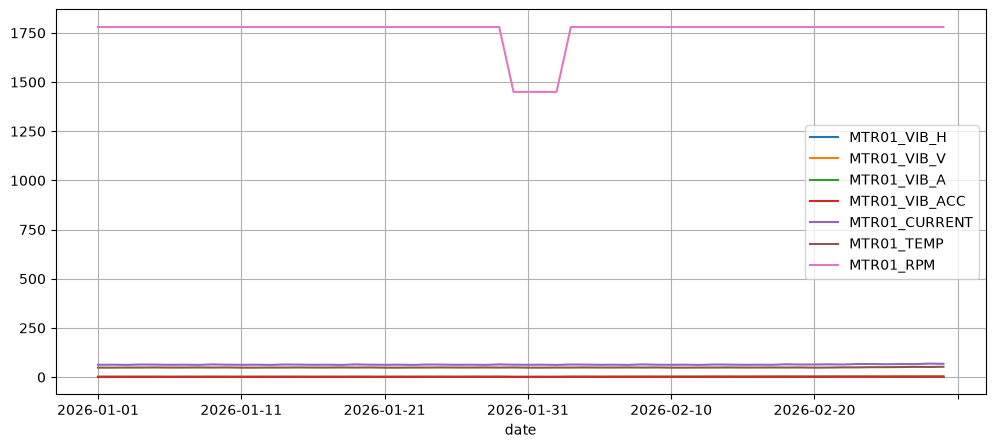

In [29]:
df_03_01[
    ["date"] + mtr_cols
].plot(
    x = "date",
    figsize=(12, 5),
    grid = True
)

# 보유 컬럼과 대조


| 필요 컬럼 | 보유 여부 | 실제 태그 명 |
|:---:|:---:|:---:|
| 모터 진동 가속도 PEAK | O | MTR01_VIB_ACC |
| 모터 진동 속도 RMS | O | MTR01_VIB_H |
| 모터 베어링 온도 | O | MTR01_TEMP |
| 모터 전류 | O | MTR01_CURRENT |
| 모터 회전수 | O | MTR01_RPM |


## **CASE B — 1번 팬, 분진 축적에 따른 불평형 감지**

### Step 1. 고장 유형과 물리량 도출

목표 고장 유형: 1번 팬 - 분진 축적에 따른 불평형 감지
진행 속도: 생각했던 것과 달리, 1번 팬은 느리다


| 구분 | 물리량 | 그 물리량을 고른 이유 |
|---|---|---|
| 주 신호 | 진동 | 팬애 분진이 쌓이면 회전체 질량 불균형으로 진동이 증가한다 |
| 확인 신호 1 | 전류 | 불평형으로 회전 부하가 걸리면 모터 전류가 변할 수 있다 |
| 확인 신호 2 | 온도 | 진동과 부하가 계속되면 베어링 또는 모터 온도가 상승할 수 있다 |